# Predict RF location (x, y) from response matrix — simple MLP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RESULTS_DIR = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")

# Load response matrix and RF locations
response_matrix = np.load(RESULTS_DIR / "ephys_response_matrix.npy")
unit_ids_df     = pd.read_csv(RESULTS_DIR / "ephys_unit_ids.csv")
rf_df           = pd.read_csv(RESULTS_DIR / "ephys_rf_unit_info.csv")

# Merge to align RF x,y with response matrix rows
merged = unit_ids_df.merge(rf_df[['unit_id', 'rf_center_x', 'rf_center_y', 'rf_r_squared']], on='unit_id', how='left')
valid  = (
    merged['rf_center_x'].notna() & merged['rf_center_y'].notna() &
    (merged['rf_center_x'] != 40)  & (merged['rf_center_x'] != -40) &
    (merged['rf_center_y'] != 40)  & (merged['rf_center_y'] != -40) &
    (merged['rf_r_squared'] >= 0.5)
)

X = response_matrix[valid.values]                                          # features: response matrix
Y = merged.loc[valid, ['rf_center_x', 'rf_center_y']].values              # targets: RF x, y

# Z-score each unit's response across conditions
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")


X shape: (3873, 100)
Y shape: (3873, 2)


In [2]:
N = 9  # 9x9 grid

# --- Bin on the full dataset so train/test share one fixed grid ---
x_edges = np.linspace(Y[:, 0].min(), Y[:, 0].max(), N + 1)
y_edges = np.linspace(Y[:, 1].min(), Y[:, 1].max(), N + 1)
bx = np.clip(np.digitize(Y[:, 0], x_edges[1:-1]), 0, N - 1)
by = np.clip(np.digitize(Y[:, 1], y_edges[1:-1]), 0, N - 1)
labels = by * N + bx                       # single class 0..80

# Drop bins with only 1 neuron (can't stratify-split)
counts = np.bincount(labels, minlength=N * N)
keep = counts[labels] >= 2
X_k, Y_k, labels_k = X[keep], Y[keep], labels[keep]
print(f"Dropped {(~keep).sum()} singleton-bin units, {keep.sum()} remaining")

# --- Stratified split: carries X, continuous Y, and bin labels together ---
X_train, X_test, Y_train, Y_test, lbl_train, lbl_test = train_test_split(
    X_k, Y_k, labels_k,
    test_size=0.2,
    random_state=42,
    stratify=labels_k,
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# --- Regularized classifier ---
clf = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=1.0,                 # strong L2
    early_stopping=True,
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)
clf.fit(X_train, lbl_train)

pred = clf.predict(X_test)
px, py = pred % N, pred // N               # decode predicted grid coords
tx, ty = lbl_test % N, lbl_test // N       # decode true grid coords


Dropped 1 singleton-bin units, 3872 remaining


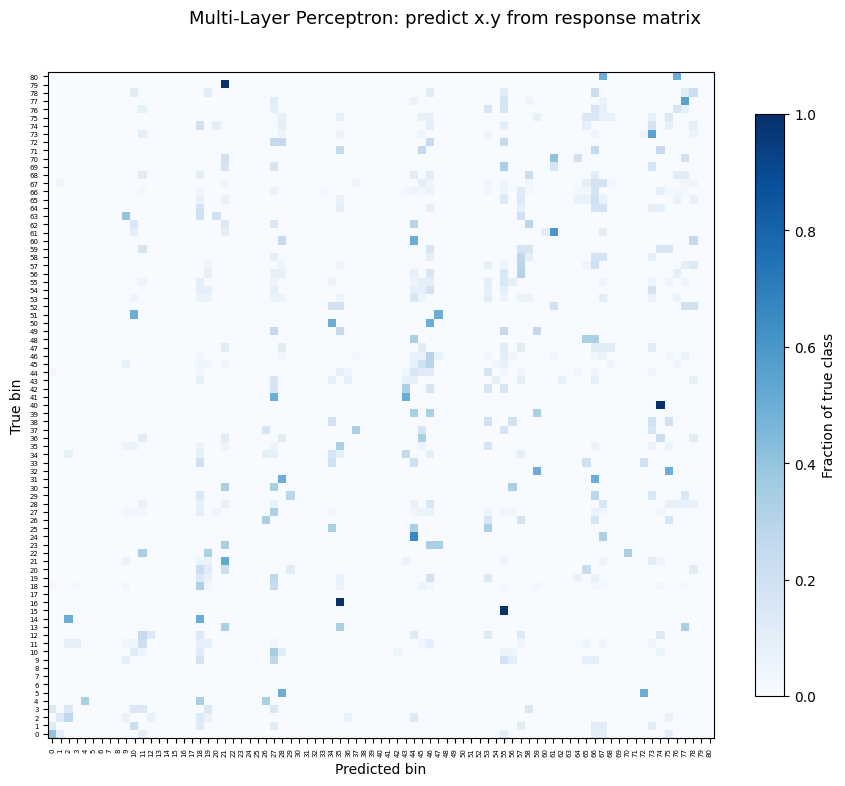

In [3]:
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score

bin_labels = list(range(N * N))  # 0..80

fig, ax = plt.subplots(figsize=(9, 8))

cm = confusion_matrix(lbl_test, pred, labels=bin_labels, normalize='true')
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1, origin='lower')
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, fontsize=5, rotation=90)
ax.set_yticks(range(len(bin_labels)))
ax.set_yticklabels(bin_labels, fontsize=5)
ax.set_xlabel("Predicted bin")
ax.set_ylabel("True bin")

acc     = accuracy_score(lbl_test, pred)
bal_acc = balanced_accuracy_score(lbl_test, pred)

plt.colorbar(im, ax=ax, label="Fraction of true class", shrink=0.8)

fig.suptitle("Multi-Layer Perceptron: predict x.y from response matrix", fontsize=13)
fig.tight_layout()
plt.show()

# Predict Probe from response matrix — simple MLP

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

RESULTS_DIR = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")

# Load response matrix and RF locations
response_matrix_df = np.load(RESULTS_DIR / "ephys_response_matrix.npy")
unit_ids_df     = pd.read_csv(RESULTS_DIR / "ephys_unit_ids.csv")
rf_df           = pd.read_csv(RESULTS_DIR / "ephys_rf_unit_info.csv")

# Merge to align RF x,y with response matrix rows
merged = unit_ids_df.merge(rf_df[['unit_id', 'rf_center_x', 'rf_center_y', 'rf_r_squared', 'probe', 'mouse_name', 'snr']], on='unit_id', how='left')
mask  = (
    merged['rf_center_x'].notna() & merged['rf_center_y'].notna() &
    (merged['rf_center_x'] != 40)  & (merged['rf_center_x'] != -40) &
    (merged['rf_center_y'] != 40)  & (merged['rf_center_y'] != -40) &
    (merged['rf_r_squared'] >= 0.5)
)

# X = response_matrix[valid.values]                                          # features: response matrix
# Y = merged.loc[valid, ['probe']].values              # targets: RF x, y

# # Z-score each unit's response across conditions
# X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# print(f"X shape: {X.shape}")
# print(f"Y shape: {Y.shape}")


rf_df_filtered = rf_df[mask]
print(f"Filtered RF info shape: {rf_df_filtered.shape}")

unit_ids_df_filtered = unit_ids_df[unit_ids_df["unit_id"].isin(rf_df_filtered["unit_id"])]
print(f"Filtered unit IDs shape: {unit_ids_df_filtered.shape}")

response_matrix_df_filtered = response_matrix_df[unit_ids_df["unit_id"].isin(rf_df_filtered["unit_id"])]
print(f"Filtered response matrix shape: {response_matrix_df_filtered.shape}")

Filtered RF info shape: (3873, 17)
Filtered unit IDs shape: (3873, 1)
Filtered response matrix shape: (3873, 100)


In [20]:
norms_raw = np.linalg.norm(response_matrix_df_filtered, axis=1)
nonzero_mask = norms_raw > 0
print(f"  Dropping {(~nonzero_mask).sum()} silent units")

response_matrix_df_filtered = response_matrix_df_filtered[nonzero_mask]
unit_ids_df_filtered = unit_ids_df_filtered[nonzero_mask].reset_index(drop=True)

# filter rf_df_filtered
rf_df_filtered = rf_df_filtered[nonzero_mask].reset_index(drop=True)

### adding in removing rate axis ###
response_meansub = response_matrix_df_filtered - response_matrix_df_filtered.mean(axis=1, keepdims=True)
response_norm = normalize(response_meansub, norm='l2')

  Dropping 12 silent units


In [26]:
X = response_norm
Y = rf_df_filtered[['probe']].values

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (3861, 100)
Y shape: (3861, 1)


In [22]:
from sklearn.preprocessing import LabelEncoder

labels = Y[:, 0]   # probe name strings

# Drop any singletons
unique, counts = np.unique(labels, return_counts=True)
keep = np.isin(labels, unique[counts >= 2])
X_k, labels_k = X[keep], labels[keep]
print(f"Probes: {dict(zip(unique, counts))}")
print(f"Dropped {(~keep).sum()} singleton units, {keep.sum()} remaining")

# Encode string labels as integers
le = LabelEncoder()
labels_enc = le.fit_transform(labels_k)

# --- Stratified split ---
X_train, X_test, lbl_train, lbl_test = train_test_split(
    X_k, labels_enc,
    test_size=0.2,
    random_state=42,
    stratify=labels_enc,
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# --- Regularized classifier ---
clf = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=1.0,
    early_stopping=True,
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)
clf.fit(X_train, lbl_train)

pred = clf.predict(X_test)

class_counts = np.bincount(labels_enc)
weights = class_counts / class_counts.sum()
weighted_chance = (weights ** 2).sum()  # sum of p_i^2
acc = (pred == lbl_test).mean()

print(f"\nTest accuracy: {acc:.3f}  (weighted chance = {weighted_chance:.3f},  n probes = {len(le.classes_)})")


Probes: {'sub-810531': np.int64(593), 'sub-810532': np.int64(341), 'sub-813810': np.int64(669), 'sub-815152': np.int64(564), 'sub-816305': np.int64(480), 'sub-816308': np.int64(260), 'sub-817334': np.int64(465), 'sub-817335': np.int64(489)}
Dropped 0 singleton units, 3861 remaining

Test accuracy: 0.664  (weighted chance = 0.133,  n probes = 8)


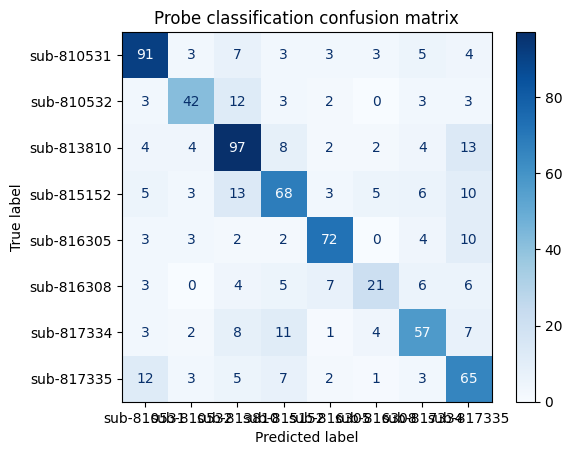

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(lbl_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Probe classification confusion matrix")
plt.show()

In [24]:
n_permutations = 100
perm_accs = []

for i in range(n_permutations):
    lbl_perm = np.random.permutation(labels_enc)
    Xtr, Xte, ltr, lte = train_test_split(X_k, lbl_perm, test_size=0.2, random_state=i, stratify=lbl_perm)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    clf_p = MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0, early_stopping=True, n_iter_no_change=15, max_iter=1000, random_state=i)
    clf_p.fit(Xtr, ltr)
    perm_accs.append((clf_p.predict(Xte) == lte).mean())

p_val = (np.array(perm_accs) >= acc).mean()
print(f"Permutation p-value: {p_val:.4f}")

Permutation p-value: 0.0000


In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0, early_stopping=True, n_iter_no_change=15, max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for tr, te in cv.split(X_k, labels_enc):
    pipe.fit(X_k[tr], labels_enc[tr])
    cv_scores.append((pipe.predict(X_k[te]) == labels_enc[te]).mean())

print(f"CV accuracy: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")

CV accuracy: 0.623 ± 0.011
